# Empirische Evaluation und statistische Analyse
**Forschungsprojekt:** Prototyp-Evaluierung eines KI-Sales-Agenten im E-Commerce  
**Autor:** Fabian Fürst  
**Datum:** Juni 2026  
**Datensatz:** SoSci-Umfrage-Export ($N = 68$ gültige Fälle)

---

Dieses Jupyter-Notebook enthält die vollständige quantitative Evaluierung und statistische Analyse für den empirischen Teil dieser Thesis. Das Hauptziel ist die Bewertung der Benutzerfreundlichkeit, Akzeptanz und Nutzermerkmale des entwickelten Prototyps.

Die Analyse ist chronologisch in folgende Schritte strukturiert:
1. Datenimport und -bereinigung: Einlesen der Rohdaten, Aussortieren unvollständiger Datensätze sowie die zeitbasierte Ausreißerbehandlung ($85 \rightarrow 66 \rightarrow 57$).
2. Skalentransformationen: Methodische Vorbereitung der Messinstrumente (Umpolen des negativen TAEG-S-Items, SUS-Score-Transformation von 0 bis 100 und dimensionsbezogene TAM-Aggregation).
3. Globale deskriptive Statistik: Berechnung von Mittelwert ($\bar{x}$), Median ($\tilde{x}$) und Standardabweichung ($s$) für alle Kernmetriken der Gesamtstichprobe ($N = 57$).
4. Subgruppenanalyse: Durchführung des Median-Splits auf Basis des TAEG-S-Gesamtwerts zur Segmentierung und zum deskriptiven Vergleich der Nutzergruppen (geringere vs. höhere Technikaffinität) sowie ergänzend eine getrennte Auswertung nach Geschlecht (`DE02`).
5. Datenvisualisierung: Generierung publikationsreifer Boxplots und Diagramme (z. B. Verteilung der Bearbeitungszeit, SUS-Scores nach Nutzergruppe) für Technikaffinität und Geschlecht, die direkt für die Thesis exportiert werden.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 1. Datenimport und -bereinigung

In [2]:
csv_path = Path("..") / "data" / "data_usability-akzeptanz-sales-agent.csv"
df = pd.read_csv(csv_path, encoding="utf-16")
df.head()

,CASE,SERIAL,REF,QUESTNNR,MODE,STARTED,DE01_01,DE02,DE03_01,DE04,...,MAILSENT,LASTDATA,STATUS,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI
0,Interview-Nummer (fortlaufend),Personenkennung oder Teilnahmecode (sofern ver...,Referenz (sofern im Link angegeben),"Fragebogen, der im Interview verwendet wurde",Interview-Modus,Zeitpunkt zu dem das Interview begonnen hat (E...,Alter: ... Jahre,Geschlecht,Affinität Shopping: [Keine Beschreibung] 01,Endgerät,...,Versandzeitpunkt der Einladungsmail (nur für n...,Zeitpunkt als der Datensatz das letzte mal geä...,Status des Interviews (Markierung),Wurde die Befragung abgeschlossen (letzte Seit...,Hat der Teilnehmer den Fragebogen nur angesehe...,"Seite, die der Teilnehmer zuletzt bearbeitet hat","Letzte Seite, die im Fragebogen bearbeitet wurde",Anteil fehlender Antworten in Prozent,Anteil fehlender Antworten (gewichtet nach Rel...,Ausfüll-Geschwindigkeit (relativ)
1,34,NaN,NaN,base,interview,2026-06-04 20:20:59,26,2,5,1,...,NaN,2026-06-04 20:29:03,complete,1,0,7,7,0,0,1.09
2,36,NaN,NaN,base,interview,2026-06-04 20:35:57,66,1,5,2,...,NaN,2026-06-04 20:43:22,complete,1,0,7,7,0,0,1.04
3,37,NaN,NaN,base,interview,2026-06-04 20:36:00,63,2,5,2,...,NaN,2026-06-04 21:03:43,complete,1,0,7,7,0,0,0.37
4,39,NaN,NaN,base,interview,2026-06-04 20:42:36,23,2,5,2,...,NaN,2026-06-04 20:54:28,complete,1,0,7,7,0,0,0.73


In [3]:
# Drop columns that only contain metadata or are empty after the first row
empty_after_first_row = df.iloc[1:].isna().all(axis=0)
df = df.loc[:, ~empty_after_first_row]
df = df.drop(columns=["CASE", "QUESTNNR", "MODE", "RG01_CP", "LASTPAGE", "MAXPAGE", "MISSING", "MISSREL"])
df.head()

,STARTED,DE01_01,DE02,DE03_01,DE04,EI02,RG01,SU01_01,SU01_02,SU01_03,...,TIME004,TIME005,TIME006,TIME007,TIME_SUM,LASTDATA,STATUS,FINISHED,Q_VIEWER,TIME_RSI
0,Zeitpunkt zu dem das Interview begonnen hat (E...,Alter: ... Jahre,Geschlecht,Affinität Shopping: [Keine Beschreibung] 01,Endgerät,Consent,Zufallsgenerator Szenario: Gezogener Code,"System Usability Scale (SUS): Ich denke, dass ...",System Usability Scale (SUS): Ich fand das Sys...,System Usability Scale (SUS): Ich fand das Sys...,...,Verweildauer Seite 4,Verweildauer Seite 5,Verweildauer Seite 6,Verweildauer Seite 7,Verweildauer gesamt (ohne Ausreißer),Zeitpunkt als der Datensatz das letzte mal geä...,Status des Interviews (Markierung),Wurde die Befragung abgeschlossen (letzte Seit...,Hat der Teilnehmer den Fragebogen nur angesehe...,Ausfüll-Geschwindigkeit (relativ)
1,2026-06-04 20:20:59,26,2,5,1,1,2,5,5,5,...,113,214,49,30,484,2026-06-04 20:29:03,complete,1,0,1.09
2,2026-06-04 20:35:57,66,1,5,2,1,1,4,2,4,...,80,163,71,39,445,2026-06-04 20:43:22,complete,1,0,1.04
3,2026-06-04 20:36:00,63,2,5,2,1,2,5,1,1,...,255,882,261,64,1434,2026-06-04 21:03:43,complete,1,0,0.37
4,2026-06-04 20:42:36,23,2,5,2,1,2,5,1,5,...,140,352,82,39,712,2026-06-04 20:54:28,complete,1,0,0.73


In [4]:
# Only use rows where STATUS == 'complete'
df = df[df['STATUS'].fillna('').str.strip().str.lower() == 'complete'].reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 46 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   STARTED   66 non-null     str  
 1   DE01_01   63 non-null     str  
 2   DE02      66 non-null     str  
 3   DE03_01   66 non-null     str  
 4   DE04      66 non-null     str  
 5   EI02      66 non-null     str  
 6   RG01      66 non-null     str  
 7   SU01_01   66 non-null     str  
 8   SU01_02   66 non-null     str  
 9   SU01_03   66 non-null     str  
 10  SU01_04   66 non-null     str  
 11  SU01_05   66 non-null     str  
 12  SU01_06   66 non-null     str  
 13  SU01_07   66 non-null     str  
 14  SU01_08   66 non-null     str  
 15  SU01_09   66 non-null     str  
 16  SU01_10   66 non-null     str  
 17  SZ03      66 non-null     str  
 18  SZ03_01   66 non-null     str  
 19  SZ04      66 non-null     str  
 20  SZ04_01   66 non-null     str  
 21  SZ05      66 non-null     str  
 22  SZ06      66 no

In [5]:
cols_to_int = [
    "DE01_01", "DE02", "DE03_01", "DE04", "EI02", "RG01",
    "SU01_01", "SU01_02", "SU01_03", "SU01_04", "SU01_05",
    "SU01_06", "SU01_07", "SU01_08", "SU01_09", "SU01_10",
    "SZ03_01", "SZ04_01", "SZ05", "SZ06",
    "TA01_01", "TA01_02", "TA01_03", "TA01_04", "TA01_05", "TA01_06",
    "TG01_01", "TG01_02", "TG01_03", "TG01_04"
]

# numerische Spalten
df[cols_to_int] = df[cols_to_int].apply(pd.to_numeric, errors="coerce").astype("Int64")

df[cols_to_int].head()

,DE01_01,DE02,DE03_01,DE04,EI02,RG01,SU01_01,SU01_02,SU01_03,SU01_04,...,TA01_01,TA01_02,TA01_03,TA01_04,TA01_05,TA01_06,TG01_01,TG01_02,TG01_03,TG01_04
0,26,2,5,1,1,2,5,5,5,1,...,5,5,5,5,5,5,3,4,3,1
1,66,1,5,2,1,1,4,2,4,1,...,5,4,4,5,5,4,3,4,3,3
2,63,2,5,2,1,2,5,1,1,1,...,5,5,5,5,5,5,2,5,3,3
3,23,2,5,2,1,2,5,1,5,1,...,5,5,5,5,5,5,4,5,1,5
4,29,1,4,2,1,1,3,2,4,1,...,4,4,3,4,4,5,5,4,3,4


In [6]:
# STARTED und LASTDATA in datetime umwandeln
df["STARTED_dt"] = pd.to_datetime(df["STARTED"], errors="coerce")
df["LASTDATA_dt"] = pd.to_datetime(df["LASTDATA"], errors="coerce")

# Bearbeitungszeit berechnen
df["Bearbeitungszeit_min"] = (df["LASTDATA_dt"] - df["STARTED_dt"]).dt.total_seconds() / 60

pd.isna(df["Bearbeitungszeit_min"]).sum()

np.int64(0)

In [7]:
# Kennwerte berechnen
bearbeitungszeit = df["Bearbeitungszeit_min"]

median = bearbeitungszeit.median()
q1 = bearbeitungszeit.quantile(0.25)
q3 = bearbeitungszeit.quantile(0.75)
minimum = bearbeitungszeit.min()
maximum = bearbeitungszeit.max()

print("Bearbeitungszeit (in Minuten):")
print(f"Median: {median:.2f}")
print(f"Unteres Quartil (Q1): {q1:.2f}")
print(f"Oberes Quartil (Q3): {q3:.2f}")
print(f"Minimum: {minimum:.2f}")
print(f"Maximum: {maximum:.2f}")

Bearbeitungszeit (in Minuten):
Median: 11.60
Unteres Quartil (Q1): 7.28
Oberes Quartil (Q3): 15.77
Minimum: 1.10
Maximum: 466.95


In [8]:
# Filter für Bearbeitungszeit auf Basis von Median und IQR
bearbeitungszeit = df["Bearbeitungszeit_min"]

q1 = bearbeitungszeit.quantile(0.25)
q3 = bearbeitungszeit.quantile(0.75)
iqr = q3 - q1
median = bearbeitungszeit.median()

untergrenze = median * 0.40
obergrenze = q3 + 1.5 * iqr

valid_time_mask = bearbeitungszeit.between(untergrenze, obergrenze, inclusive="both")
removed_rows = (~valid_time_mask).sum()

print("Grenzen für die Bearbeitungszeit (in Minuten):")
print(f"Median: {median:.2f}")
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Untergrenze (40 % des Medians): {untergrenze:.2f}")
print(f"Obergrenze (Q3 + 1,5 * IQR): {obergrenze:.2f}")
print(f"Entfernte Zeilen: {removed_rows}")

# Nur plausible Fälle behalten
df = df.loc[valid_time_mask].reset_index(drop=True)
bearbeitungszeit = df["Bearbeitungszeit_min"]
print(f"Verbleibende Zeilen: {len(df)}")

Grenzen für die Bearbeitungszeit (in Minuten):
Median: 11.60
Q1: 7.28
Q3: 15.77
IQR: 8.49
Untergrenze (40 % des Medians): 4.64
Obergrenze (Q3 + 1,5 * IQR): 28.50
Entfernte Zeilen: 9
Verbleibende Zeilen: 57


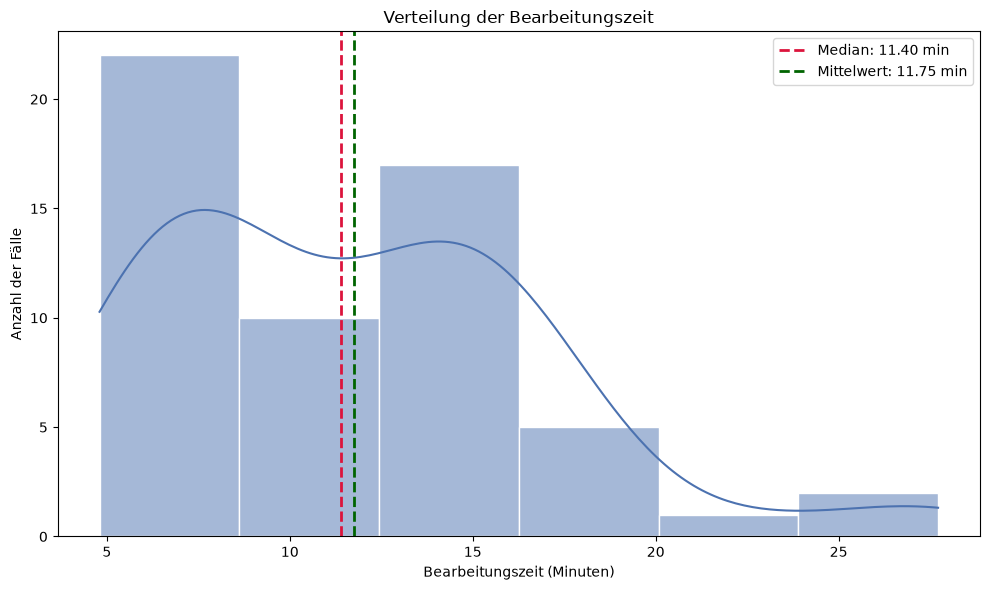

In [9]:
# Verteilung der Bearbeitungszeit in Minuten
plt.figure(figsize=(10, 6))

sns.histplot(
    bearbeitungszeit,
    bins="fd",
    kde=True,
    color="#4C72B0",
    edgecolor="white"
)

plt.axvline(bearbeitungszeit.median(), color="crimson", linestyle="--", linewidth=2, label=f"Median: {bearbeitungszeit.median():.2f} min")
plt.axvline(bearbeitungszeit.mean(), color="darkgreen", linestyle="--", linewidth=2, label=f"Mittelwert: {bearbeitungszeit.mean():.2f} min")

plt.title("Verteilung der Bearbeitungszeit")
plt.xlabel("Bearbeitungszeit (Minuten)")
plt.ylabel("Anzahl der Fälle")
plt.legend()
plt.tight_layout()
plt.show()

DE01_01 ist die Altersangabe und dementsprechend zu vernachlässigen.

## 2. Skalentransformation

### TAEG: Invertierung und Score-Berechnung

In [10]:
# Das negative Item invertieren (aus 1 wird 5, aus 2 wird 4 etc.)
df["TG01_01_reversed"] = 6 - pd.to_numeric(df["TG01_01"], errors="coerce")

# Liste der korrekten Items definieren
taeg_items = ['TG01_01_reversed', 'TG01_02', 'TG01_03', 'TG01_04']

# Zeilenmittelwert berechnen
df['TAEG_S_Score'] = df[taeg_items].mean(axis=1)

print("NaNs: "+str(pd.isna(df["TG01_01_reversed"]).sum()))
display(df['TAEG_S_Score'].head())

NaNs: 0


0    2.75
1    3.25
2    3.75
3    3.25
4     3.0
Name: TAEG_S_Score, dtype: Float64

### SUS: Berechnung des Gesamtwerts

In [11]:
# Erstellen eines df nur mit den SUS-Items,um die Reihenfolge der Transformation zu erleichtern
sus_items = [
    "SU01_01", "SU01_02", "SU01_03", "SU01_04", "SU01_05",
    "SU01_06", "SU01_07", "SU01_08", "SU01_09", "SU01_10"
]

for item in sus_items:
    df[item] = pd.to_numeric(df[item], errors='coerce')

sus_transformed = pd.DataFrame(index=df.index)

# Die mathematische Transformation nach John Brooke anwenden
for idx, item in enumerate(sus_items, start=1):
    if idx % 2 != 0:
        # Ungerade Items (1, 3, 5, 7, 9): Wert - 1
        sus_transformed[item] = df[item] - 1
    else:
        # Gerade Items (2, 4, 6, 8, 10): 5 - Wert
        sus_transformed[item] = 5 - df[item]

# Summe berechnen und mit 2,5 multiplizieren für den finalen Score (0 bis 100)
df['SUS_Score'] = sus_transformed.sum(axis=1) * 2.5

display(df[['SUS_Score']].head())

,SUS_Score
0,85.0
1,77.5
2,80.0
3,100.0
4,77.5


### TAM: AGGREGATION DER TAM-DIMENSIONEN (PU & PEOU)

In [12]:
# Definition der Items nach theoretischer Zuordnung
tam_pu_items = ['TA01_01', 'TA01_02']
tam_peou_items = ['TA01_04', 'TA01_05', 'TA01_06']

# Sicherstellen, dass alle Werte als Zahlen formatiert sind
all_tam_items = [f'TA01_{i:02d}' for i in range(1, 7)]
for item in all_tam_items:
    df[item] = pd.to_numeric(df[item], errors='coerce')

# Berechnung der Dimensionen als arithmetischer Mittelwert pro Zeile
df['TAM_PU'] = df[tam_pu_items].mean(axis=1)
df['TAM_PEOU'] = df[tam_peou_items].mean(axis=1)

# Das Item [03] direkt als eigene Kernmetrik (Nutzungsintention) abspeichern
df['TAM_BI'] = df['TA01_03']

# Erste Zeilen zur Kontrolle ausgeben
print("Die ersten berechneten TAM-Scores:")
display(df[['TAM_PU', 'TAM_PEOU', 'TAM_BI']].head())

Die ersten berechneten TAM-Scores:


,TAM_PU,TAM_PEOU,TAM_BI
0,5.0,5.0,5
1,4.5,4.666667,4
2,5.0,5.0,5
3,5.0,5.0,5
4,4.0,4.333333,3


## 3. Globale deskriptive Statistik

In [13]:
# Definition aller berechneten Kernmetriken
core_metrics = ['TAEG_S_Score', 'SUS_Score', 'TAM_PU', 'TAM_PEOU', 'TAM_BI']

# Berechnung von Mittelwert, Median und Standardabweichung
global_stats = df[core_metrics].describe().loc[['mean', '50%', 'std']]
global_stats.index = ['Arithmetischer Mittelwert (x̄)', 'Median (x̃)', 'Standardabweichung (s)']
global_stats.columns = [
    'Technikaffinität (TAEG-S)', 
    'System Usability (SUS)', 
    'Wahrgenommene Nützlichkeit (TAM_PU)', 
    'Bedienungsfreundlichkeit (TAM_PEOU)', 
    'Nutzungsintention (TAM_BI)'
]

# Ergebnisse gerundet auf 2 Nachkommastellen anzeigen
print("Globale deskriptive Kennwerte der Gesamtstichprobe (N = 57):")
display(global_stats.round(2))

Globale deskriptive Kennwerte der Gesamtstichprobe (N = 57):


,Technikaffinität (TAEG-S),System Usability (SUS),Wahrgenommene Nützlichkeit (TAM_PU),Bedienungsfreundlichkeit (TAM_PEOU),Nutzungsintention (TAM_BI)
Arithmetischer Mittelwert (x̄),3.55,75.83,4.07,4.23,3.54
Median (x̃),3.5,77.5,4.5,4.33,4.0
Standardabweichung (s),0.54,14.63,0.98,0.85,1.2


### Interpretation der globalen deskriptiven Statistik (Gesamtstichprobe N = 57)

Die fächerübergreifende Analyse der Gesamtstichprobe liefert ein erstes klares Bild über die Akzeptanz und Usability des KI-Agenten CtxCommerce:

* Überdurchschnittliche Usability (SUS): Mit einem globalen Mittelwert von $75.83$ (Median: $77.5$; $s = 14.63$) überschreitet der Next.js-Prototyp den wissenschaftlich etablierten Usability-Benchmark von 68 nach Bangor et al. (2008) deutlich. Das System wird somit kollektiv in der Kategorie "Good" bis "Excellent" verortet und als hochgradig akzeptabel eingestuft.
* Hohe funktionale und ergonomische Güte (TAM_PEOU & TAM_PU): Die subjektive Bedienungsfreundlichkeit schneidet mit einem Mittelwert von $4.23$ ($s = 0.85$) auf der 5-stufigen Likert-Skala exzellent ab. Korrespondierend dazu wird auch die wahrgenommene Nützlichkeit mit $\bar{x} = 4.07$ ($s = 0.98$) sehr hoch bewertet. Der KI-Agent wird demnach als intuitiv bedienbar und als echter funktionaler Mehrwert im E-Commerce-Suchprozess erlebt.
* Moderate Verhaltensintention (TAM_BI): Die zukünftige Nutzungsintention fällt im Verhältnis zu den performativen Faktoren etwas verhaltener, aber mit $\bar{x} = 3.54$ ($s = 1.2$) dennoch positiv (oberhalb der neutralen Skalenmitte von 3.0) aus. Die höhere Standardabweichung zeigt hierbei die größte psychologische Varianz im Antwortverhalten der Probanden.
* Homogene Nutzerbasis (TAEG-S): Die Probanden weisen eine moderate, in sich sehr homogene Technikaffinität auf ($\bar{x} = 3.55$; $s = 0.54$). Extremwerte (Verweigerer oder Core-Techies) sind in der Stichprobe kaum vertreten.

**Fazit:** In der Gesamtschau erzielt das Artefakt über alle Kernmetriken hinweg positive Bewertungen. Um methodisch zu prüfen, ob diese Ergebnisse maßgeblich durch die individuelle Technikaffinität moderiert werden, schließt sich im nächsten Schritt die differenzierte Subgruppenanalyse an.

## 4. Subgruppenanalyse

In [16]:
# Festlegen des Medians aus der globalen Analyse
taeg_median_value = 3.5

# Einteilung der Probanden in zwei Gruppen (Median-Split)
# Gruppe 0: Eher technikfern (Wert kleiner oder gleich Median)
# Gruppe 1: Eher technikaffin (Wert größer als Median)
df['TAEG_Gruppe'] = np.where(df['TAEG_S_Score'] <= taeg_median_value, 'Technikfern (<= 3.5)', 'Technikaffin (> 3.5)')

# Verteilung der Probanden auf die Gruppen kontrollieren
print("Verteilung der Stichprobe nach dem Median-Split:")
print(df['TAEG_Gruppe'].value_counts())
print("-" * 60)

# Liste der zu vergleichenden Kernmetriken (ohne TAEG selbst)
comparison_metrics = ['SUS_Score', 'TAM_PU', 'TAM_PEOU', 'TAM_BI']

# Deskriptive Statistiken getrennt nach Gruppen berechnen
group_stats = df.groupby('TAEG_Gruppe')[comparison_metrics].agg(['mean', 'std']).T

# Zeilen für wissenschaftliche Darstellung umbenennen
group_stats.index.names = ['Kernmetrik', 'Kennwert']
group_stats = group_stats.rename(index={
    'mean': 'Mittelwert (x̄)', 
    'std': 'Standardabweichung (s)',
    'SUS_Score': 'System Usability (SUS)',
    'TAM_PU': 'Wahrgenommene Nützlichkeit (TAM_PU)',
    'TAM_PEOU': 'Bedienungsfreundlichkeit (TAM_PEOU)',
    'TAM_BI': 'Nutzungsintention (TAM_BI)'
})

print("\nVergleich der Kernmetriken zwischen den beiden Subgruppen:")
display(group_stats.round(2))

Verteilung der Stichprobe nach dem Median-Split:
TAEG_Gruppe
Technikfern (<= 3.5)    31
Technikaffin (> 3.5)    26
Name: count, dtype: int64
------------------------------------------------------------

Vergleich der Kernmetriken zwischen den beiden Subgruppen:


TAEG_Gruppe                                                 Technikaffin (> 3.5)  \
Kernmetrik                          Kennwert                                       
System Usability (SUS)              Mittelwert (x̄)                        77.98   
                                    Standardabweichung (s)                 12.51   
Wahrgenommene Nützlichkeit (TAM_PU) Mittelwert (x̄)                         4.23   
                                    Standardabweichung (s)                  0.82   
Bedienungsfreundlichkeit (TAM_PEOU) Mittelwert (x̄)                         4.47   
                                    Standardabweichung (s)                  0.45   
Nutzungsintention (TAM_BI)          Mittelwert (x̄)                         3.65   
                                    Standardabweichung (s)                  1.32   

TAEG_Gruppe                                                 Technikfern (<= 3.5)  
Kernmetrik                          Kennwert                                      
System Usability (SUS)              Mittelwert (x̄)                        74.03  
                                    Standardabweichung (s)                 16.18  
Wahrgenommene Nützlichkeit (TAM_PU) Mittelwert (x̄)                         3.94  
                                    Standardabweichung (s)                   1.1  
Bedienungsfreundlichkeit (TAM_PEOU) Mittelwert (x̄)                         4.03  
                                    Standardabweichung (s)                  1.04  
Nutzungsintention (TAM_BI)          Mittelwert (x̄)                         3.45  
                                    Standardabweichung (s)                  1.09

### Interpretation der Subgruppenanalyse (Median-Split)

Der Median-Split der Technikaffinität ($MD = 3.5$) teilt die Stichprobe in eine eher technikfernere ($n = 31$, $\le 3.5$) und eine technikaffinere Subgruppe ($n = 26$, $> 3.5$) auf. Der deskriptive Gruppenvergleich liefert folgende zentrale Erkenntnisse für das Artefakt CtxCommerce:

* Barrierefreie Usability (SUS): Beide Gruppen attestieren dem KI-Agenten eine überdurchschnittliche System-Usability ($77.98$ vs. $74.03$). Da beide Werte deutlich über dem empirischen Usability-Benchmark von 68 (Bangor et al., 2008) liegen, ist der Next.js-Prototyp als hochgradig barrierearm und intuitiv einzustufen.
* Hohe Interaktionsqualität (TAM_PEOU): Während die technikaffine Gruppe die Bedienung als spielend einfach wahrnimmt ($\bar{x} = 4.47$; $s = 0.45$), bewertet auch die technikfernere Gruppe diese sehr positiv ($\bar{x} = 4.03$). Die höhere Streuung in der technikferneren Gruppe ($s = 1.04$) deutet jedoch auf eine leicht heterogenere Eingewöhnungszeit hin.
* Gruppenübergreifender Pragmatismus (TAM_PU & TAM_BI): Der funktionale Mehrwert des Agenten bei der Kaufentscheidung wird von beiden Gruppen gleichermaßen hoch eingeschätzt ($\bar{x} = 4.23$ vs. $\bar{x} = 3.94$). Die zukünftige Nutzungsintention (TAM_BI) fällt im Vergleich zur reinen Usability in beiden Lagern etwas moderater, aber dennoch positiv aus ($3.65$ vs. $3.45$).

**Fazit:** Der KI-Agent generiert einen robusten, technologieunabhängigen Mehrwert. Um zu prüfen, ob die leichten deskriptiven Vorteile der technikaffinen Gruppe statistisch belastbar oder rein zufällig sind, ist im nächsten Schritt eine inferenzstatistische Absicherung (Signifikanzprüfung) notwendig.

In [19]:
from IPython.display import Markdown, display

gender_map = {1: 'Männlich', 2: 'Weiblich'}
df_gender = df[df['DE02'].isin(gender_map)].copy()
df_gender['Geschlecht_Gruppe'] = df_gender['DE02'].map(gender_map)

display(Markdown('### Subgruppenanalyse nach Geschlecht'))

print('Verteilung der Stichprobe nach Geschlecht:')
print(df_gender['Geschlecht_Gruppe'].value_counts())
print('-' * 60)
print(f"Ausschluss wegen fehlender oder sonstiger Codes: {len(df) - len(df_gender)}")

# Liste der zu vergleichenden Kernmetriken (ohne Geschlecht selbst)
gender_metrics = ['SUS_Score', 'TAM_PU', 'TAM_PEOU', 'TAM_BI']

# Deskriptive Statistiken getrennt nach Geschlecht berechnen
gender_stats = df_gender.groupby('Geschlecht_Gruppe')[gender_metrics].agg(['mean', 'std']).T

gender_stats.index.names = ['Kernmetrik', 'Kennwert']
gender_stats = gender_stats.rename(index={
    'mean': 'Mittelwert (x̄)',
    'std': 'Standardabweichung (s)',
    'SUS_Score': 'System Usability (SUS)',
    'TAM_PU': 'Wahrgenommene Nützlichkeit (TAM_PU)',
    'TAM_PEOU': 'Bedienungsfreundlichkeit (TAM_PEOU)',
    'TAM_BI': 'Nutzungsintention (TAM_BI)'
})

display(Markdown('Vergleich der Kernmetriken zwischen den Geschlechtern:'))
display(gender_stats.round(2))

gender_means = df_gender.groupby('Geschlecht_Gruppe')[gender_metrics].mean()

display(Markdown(
    f"**Kurzinterpretation:** Die deskriptiven Mittelwerte liegen in beiden Geschlechtergruppen auf einem klar positiven Niveau. "
    f"Die SUS-Werte liegen bei {gender_means.loc['Männlich', 'SUS_Score']:.2f} bzw. {gender_means.loc['Weiblich', 'SUS_Score']:.2f}, "
    f"die wahrgenommene Nützlichkeit bei {gender_means.loc['Männlich', 'TAM_PU']:.2f} bzw. {gender_means.loc['Weiblich', 'TAM_PU']:.2f}, "
    f"die Bedienungsfreundlichkeit bei {gender_means.loc['Männlich', 'TAM_PEOU']:.2f} bzw. {gender_means.loc['Weiblich', 'TAM_PEOU']:.2f} und "
    f"die Nutzungsintention bei {gender_means.loc['Männlich', 'TAM_BI']:.2f} bzw. {gender_means.loc['Weiblich', 'TAM_BI']:.2f}. "
    f"Die Werte sprechen insgesamt für ein robustes Akzeptanzprofil unabhängig vom Geschlecht."
))

### Subgruppenanalyse nach Geschlecht

Verteilung der Stichprobe nach Geschlecht:
Geschlecht_Gruppe
Männlich    35
Weiblich    20
Name: count, dtype: int64
------------------------------------------------------------
Ausschluss wegen fehlender oder sonstiger Codes: 2


Vergleich der Kernmetriken zwischen den Geschlechtern:

Geschlecht_Gruppe                                           Männlich  Weiblich
Kernmetrik                          Kennwert                                  
System Usability (SUS)              Mittelwert (x̄)            72.93      81.0
                                    Standardabweichung (s)     15.56     12.31
Wahrgenommene Nützlichkeit (TAM_PU) Mittelwert (x̄)             3.93       4.3
                                    Standardabweichung (s)      1.08      0.78
Bedienungsfreundlichkeit (TAM_PEOU) Mittelwert (x̄)             4.06      4.55
                                    Standardabweichung (s)      0.98       0.5
Nutzungsintention (TAM_BI)          Mittelwert (x̄)             3.31       4.0
                                    Standardabweichung (s)      1.28      0.97

**Kurzinterpretation:** Die deskriptiven Mittelwerte liegen in beiden Geschlechtergruppen auf einem klar positiven Niveau. Die SUS-Werte liegen bei 72.93 bzw. 81.00, die wahrgenommene Nützlichkeit bei 3.93 bzw. 4.30, die Bedienungsfreundlichkeit bei 4.06 bzw. 4.55 und die Nutzungsintention bei 3.31 bzw. 4.00. Die Werte sprechen insgesamt für ein robustes Akzeptanzprofil unabhängig vom Geschlecht.

## 5. Datenvisualisierung

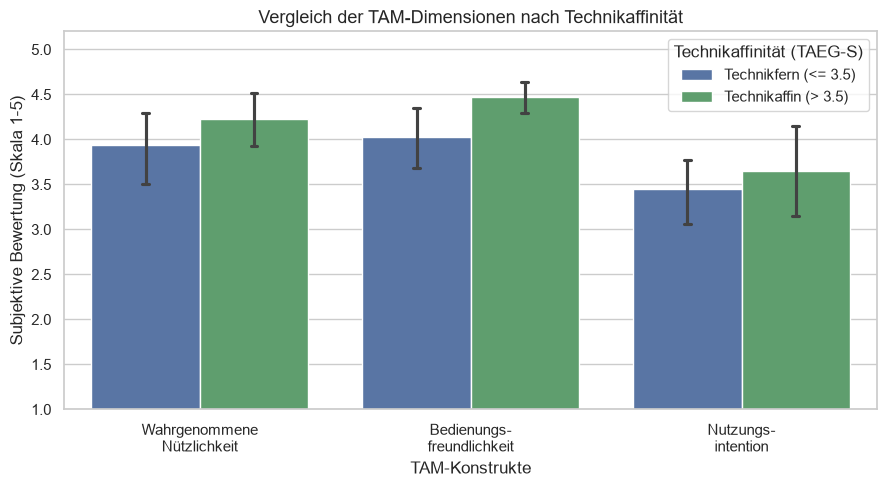

In [17]:
# Globales Design für wissenschaftliche Grafiken setzen
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})
colors = {'Technikfern (<= 3.5)': '#4c72b0', 'Technikaffin (> 3.5)': '#55a868'}

# Daten ins Langformat bringen, damit Seaborn sie gruppieren kann
tam_melt = df.melt(
    id_vars=['TAEG_Gruppe'], 
    value_vars=['TAM_PU', 'TAM_PEOU', 'TAM_BI'],
    var_name='Dimension', 
    value_name='Score'
)

tam_melt['Dimension'] = tam_melt['Dimension'].replace({
    'TAM_PU': 'Wahrgenommene\nNützlichkeit',
    'TAM_PEOU': 'Bedienungs-\nfreundlichkeit',
    'TAM_BI': 'Nutzungs-\nintention'
})

plt.figure(figsize=(9, 5))
ax1 = sns.barplot(
    data=tam_melt, 
    x='Dimension', 
    y='Score', 
    hue='TAEG_Gruppe', 
    palette=colors,
    errorbar='ci', # Zeigt das Konfidenzintervall an
    capsize=0.05
)

plt.title('Vergleich der TAM-Dimensionen nach Technikaffinität')
plt.xlabel('TAM-Konstrukte')
plt.ylabel('Subjektive Bewertung (Skala 1-5)')
plt.ylim(1, 5.2)
plt.legend(title='Technikaffinität (TAEG-S)')
plt.tight_layout()
plt.show()

print("\n" + "="*80 + "\n")

### Interpretation der TAM-Dimensionen nach Technikaffinität

Das gruppierte Balkendiagramm visualisiert den deskriptiven Vergleich der drei TAM-Konstrukte zwischen den beiden Subgruppen (Skala 1–5; Fehlerbalken zeigen das 95%-Konfidenzintervall):

* Technologieunabhängige Usability (Bedienungsfreundlichkeit): Die technikaffine Gruppe bewertet die Handhabung des Chat-Widgets erwartungsgemäß exzellent und homogen ($\bar{x} = 4.47$; kurze Fehlerantenne). Bemerkenswert ist, dass auch die technikfernere Gruppe die Bedienung mit $\bar{x} = 4.03$ als sehr einfach einstuft. Das Interface von CtxCommerce bricht somit technologische Barrieren erfolgreich auf.
* Universeller funktionaler Mehrwert (Nützlichkeit): Beide Gruppen attestieren dem KI-Agenten einen nahezu identisch hohen Nutzen bei der Kaufentscheidung ($\bar{x} = 4.23$ vs. $\bar{x} = 3.94$). Dies belegt, dass das System ein reales Problem im E-Commerce-Suchprozess löst und nicht als reines "Tech-Gimmick" wahrgenommen wird.
* Erwartbare Divergenz bei der Nutzungsintention: In beiden Lagern sinkt die konkrete Absicht zur zukünftigen Alltagsnutzung im Vergleich zur reinen Performanz leicht ab, verbleibt jedoch im positiven Bereich ($3.65$ vs. $3.45$). Diese psychologische Lücke (Acceptance Gap) zwischen hoher Systemgüte und vorsichtiger Adoptionsabsicht ist ein klassischer Befund in der IT-Akzeptanzforschung.

**Fazit:** Visuell zeigt sich ein robustes, zielgruppenübergreifendes Akzeptanzprofil. Da sich die 95%-Konfidenzintervalle (Fehlerbalken) über alle Dimensionen hinweg vertikal überschneiden, liegt die Vermutung nahe, dass die leichten Unterschiede statistisch nicht signifikant sind. Dies wird im folgenden Kapitel inferenzstatistisch überprüft.

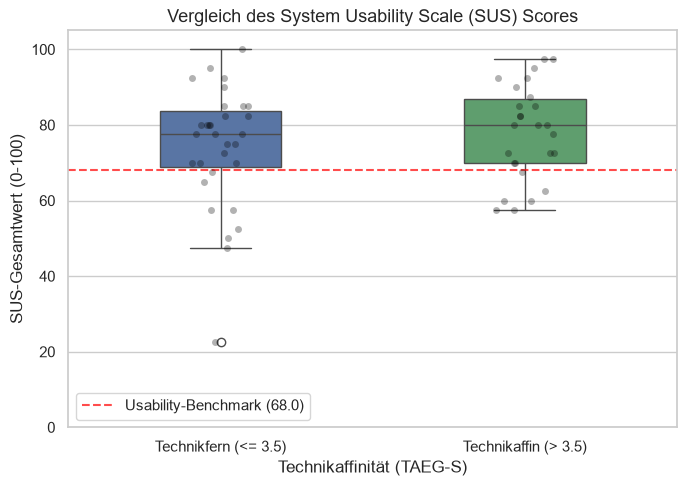

In [18]:
plt.figure(figsize=(7, 5))
ax2 = sns.boxplot(
    data=df, 
    x='TAEG_Gruppe', 
    y='SUS_Score', 
    hue='TAEG_Gruppe',
    palette=colors, 
    width=0.4,
    legend=False
)

# Einzelne Datenpunkte darüberlegen, um die Verteilung der 57 Probanden zu zeigen
sns.stripplot(
    data=df, 
    x='TAEG_Gruppe', 
    y='SUS_Score', 
    color='black', 
    alpha=0.3, 
    size=5, 
    jitter=0.1
)

plt.title('Vergleich des System Usability Scale (SUS) Scores')
plt.xlabel('Technikaffinität (TAEG-S)')
plt.ylabel('SUS-Gesamtwert (0-100)')
plt.ylim(0, 105)

# Benchmark-Linie bei 68 einzeichnen (Grenze für überdurchschnittliche Usability)
plt.axhline(y=68, color='red', linestyle='--', alpha=0.7, label='Usability-Benchmark (68.0)')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

### Datenvisualisierung nach Geschlecht

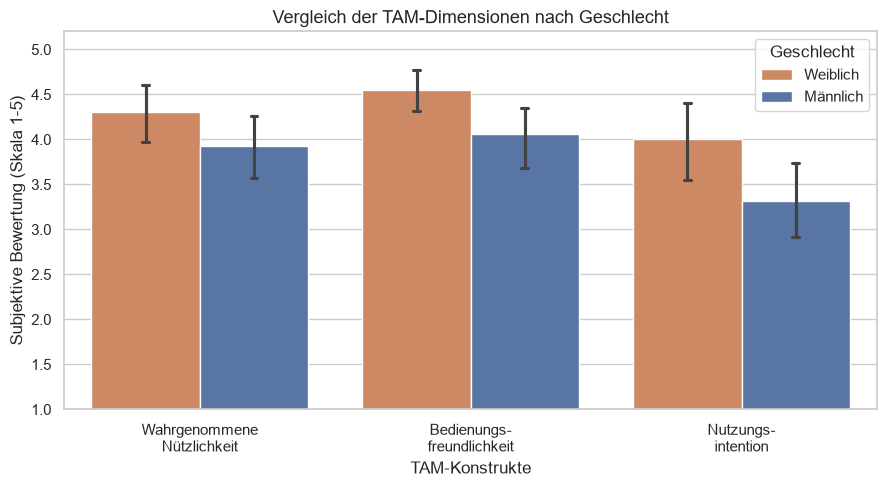

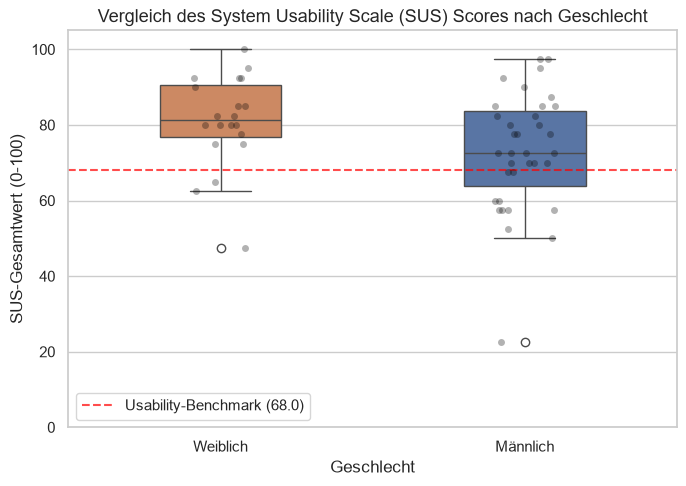

In [20]:
from IPython.display import Markdown, display

display(Markdown('### Datenvisualisierung nach Geschlecht'))

# Globales Design für wissenschaftliche Grafiken setzen
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})
gender_colors = {'Männlich': '#4c72b0', 'Weiblich': '#dd8452'}

# Daten ins Langformat bringen, damit Seaborn sie gruppieren kann
gender_tam_melt = df_gender.melt(
    id_vars=['Geschlecht_Gruppe'],
    value_vars=['TAM_PU', 'TAM_PEOU', 'TAM_BI'],
    var_name='Dimension',
    value_name='Score'
)

gender_tam_melt['Dimension'] = gender_tam_melt['Dimension'].replace({
    'TAM_PU': 'Wahrgenommene\nNützlichkeit',
    'TAM_PEOU': 'Bedienungs-\nfreundlichkeit',
    'TAM_BI': 'Nutzungs-\nintention'
})

plt.figure(figsize=(9, 5))
ax3 = sns.barplot(
    data=gender_tam_melt,
    x='Dimension',
    y='Score',
    hue='Geschlecht_Gruppe',
    palette=gender_colors,
    errorbar='ci',
    capsize=0.05
)

plt.title('Vergleich der TAM-Dimensionen nach Geschlecht')
plt.xlabel('TAM-Konstrukte')
plt.ylabel('Subjektive Bewertung (Skala 1-5)')
plt.ylim(1, 5.2)
plt.legend(title='Geschlecht')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
ax4 = sns.boxplot(
    data=df_gender,
    x='Geschlecht_Gruppe',
    y='SUS_Score',
    hue='Geschlecht_Gruppe',
    palette=gender_colors,
    width=0.4,
    legend=False
)

# Einzelne Datenpunkte darüberlegen, um die Verteilung der Stichprobe zu zeigen
sns.stripplot(
    data=df_gender,
    x='Geschlecht_Gruppe',
    y='SUS_Score',
    color='black',
    alpha=0.3,
    size=5,
    jitter=0.1
)

plt.title('Vergleich des System Usability Scale (SUS) Scores nach Geschlecht')
plt.xlabel('Geschlecht')
plt.ylabel('SUS-Gesamtwert (0-100)')
plt.ylim(0, 105)

# Benchmark-Linie bei 68 einzeichnen (Grenze für überdurchschnittliche Usability)
plt.axhline(y=68, color='red', linestyle='--', alpha=0.7, label='Usability-Benchmark (68.0)')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

print('\n' + '=' * 80 + '\n')